In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np

### Make a specific spatial region spatially unfair

**TODO.**

The idea is to partition the space with a uniform grid, select a specific cell, and then relabel the objects associated with that cell. This simulates a trajectory classifier that is unfair w.r.t. that cell's objects.

In [9]:
# Read the US Census traits
path_atlanta_tracts = './data_simulator/huge_dataset/atlanta_census_tracts_2020.geojson'
atlanta_tracts = gpd.read_file(path_atlanta_tracts)['geometry'].to_frame()
atlanta_tracts

,geometry
0,"POLYGON ((-84.5659 33.64711, -84.56586 33.6472..."
1,"POLYGON ((-84.52162 33.65584, -84.52143 33.655..."
2,"POLYGON ((-84.44736 33.73455, -84.4472 33.7354..."
3,"POLYGON ((-84.45043 33.72352, -84.4502 33.7242..."
4,"POLYGON ((-84.47687 33.70507, -84.47685 33.706..."
...,...
206,"POLYGON ((-84.37003 33.85271, -84.37 33.85362,..."
207,"POLYGON ((-84.36784 33.85737, -84.36782 33.860..."
208,"POLYGON ((-84.3817 33.88672, -84.38117 33.8868..."
209,"POLYGON ((-84.41228 33.87734, -84.41211 33.877..."


In [ ]:
# Estimate a metric CRS we can use for the area covered by the geodataframe.
orig_crs = atlanta_tracts.crs
metric_crs = atlanta_tracts.estimate_utm_crs()
print(orig_crs, metric_crs)

atlanta_tracts.to_crs(metric_crs, inplace=True)
atlanta_tracts['min_buffer'] = atlanta_tracts.geometry.maximum_inscribed_circle().length


EPSG:32616 EPSG:32616


,geometry,min_buffer
0,"POLYGON ((725735.883 3725686.817, 725738.608 3...",1205.003144
1,"POLYGON ((729819.74 3726753.14, 729837.411 372...",826.344158
2,"POLYGON ((736492.152 3735650.766, 736503.912 3...",551.278647
3,"POLYGON ((736237.902 3734420.439, 736257.032 3...",604.328011
4,"POLYGON ((733836.643 3732313.338, 733835.7 373...",722.368826
...,...,...
206,"POLYGON ((743322.699 3748936.962, 743323.642 3...",391.037624
207,"POLYGON ((743512.133 3749459.038, 743505.846 3...",476.698814
208,"POLYGON ((742147.199 3752682.456, 742195.4 375...",636.768007
209,"POLYGON ((739344.675 3751569.445, 739359.774 3...",767.668615


<Axes: >

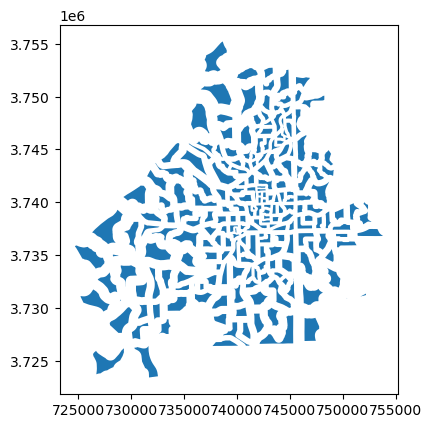

In [32]:
provaccia = atlanta_tracts.geometry.buffer(-atlanta_tracts['min_buffer'] * 0.5)
provaccia.plot()

Plot a simple map with the Atlanta 2020 US Census Tracts.

# Map the users' stop segments to the traits

In [ ]:
# Read the dataframe with the users' stop segments.
path_stop_df = './data_simulator/huge_dataset/dataset_simulator_trajectories.compressed.parquet.stops.parquet'
stop_df = pd.read_parquet(path_stop_df)
stop_df = gpd.GeoDataFrame(stop_df, 
                           geometry=gpd.points_from_xy(stop_df.lng, stop_df.lat), 
                           crs="EPSG:4326").loc[:, ['uid', 'geometry']]
# stop_df.to_crs(metric_crs, inplace=True)
stop_df


# Associated each stop segment to a tract via its centroid.
mapped_stops = stop_df.sjoin(atlanta_tracts,
                             how="left",
                             predicate="within")[['uid', 'index_right']]
mapped_stops

,uid,index_right
0,0,168
1,0,168
2,0,168
3,0,168
4,0,168
...,...,...
4393268,99999,130
4393269,99999,117
4393270,99999,122
4393271,99999,117


In [ ]:
# For each tract, count the number of users with at least a stop in that tract.
count_users_per_tract = mapped_stops.drop_duplicates()['index_right'].value_counts()

# Compute the frequency of each pair '(user, tract)'.
count_user_tract_frequency = mapped_stops.groupby(['uid', 'index_right']).size()
# count_user_tract_frequency.loc[count_user_tract_frequency >= 5]

display(count_users_per_tract)
display(count_user_tract_frequency)

In [ ]:
# TODO: IDEA for injecting unfairness => we can pick 1/2/3/4 tracts as seeds, and initially use a negative buffer to make their
# area equal to 0. 
# We then progressively expand their buffers, progressively taking in the stop segments' centroids within them, and thus
# progressively increasing the number of users affected by unfairness.

### Write the synthetic unfair labels to disk